# Chapter 137 — Vector Spaces

> **Prerequisites:** ch121 (what is a vector), ch125 (vector addition), ch126 (scalar multiplication), ch135 (orthogonality)  
> **You will learn:**
> - The abstract definition of a vector space and why it matters
> - The 8 axioms that define a vector space and how to check them
> - Examples of vector spaces beyond arrows in 3D
> - Why this abstraction is the foundation of all of linear algebra
> 
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

Until now, vectors have been lists of numbers. But mathematically, a **vector space** is any set $V$ of objects that can be added together and scaled by real numbers, following 8 axioms.

The elements of $V$ are called **vectors**, even if they are functions, matrices, polynomials, or infinite sequences — not arrows.

The payoff: every theorem proven for abstract vector spaces applies simultaneously to $\mathbb{R}^n$, to function spaces, to signal processing, to quantum mechanics. One abstraction rules all of them.

**Common misconceptions:**
- A vector space is not the same as a list of vectors. It is a set plus two operations (addition, scalar multiplication) satisfying axioms.
- The zero vector must exist in every vector space. A set without a zero element cannot be a vector space.
- Not all sets with addition and scaling are vector spaces. Each axiom must be checked.

## 2. Intuition & Mental Models

**Think of a vector space as a structured playground:** You can add any two objects in it and get another object in it. You can scale any object and stay in it. The zero object exists. Every object has an additive inverse. Nothing weird happens with scaling by 1 or combining scalings.

**Computational:** For a programmer, a vector space is like a type with two overloaded operations (`+` and scalar `*`) that are closed (always return the same type) and satisfy predictable algebraic laws.

**Why abstract?** Once you know $\mathbb{R}^n$ is a vector space, you immediately know you can apply linear algebra to it. Once you know polynomials up to degree $k$ form a vector space, you immediately know all the machinery of bases, coordinates, and transformations applies. The abstraction multiplies your knowledge.

Recall from ch125 (vector addition) and ch126 (scalar multiplication): those operations on $\mathbb{R}^n$ satisfy all 8 axioms. $\mathbb{R}^n$ is the canonical example.

## 3. Visualization

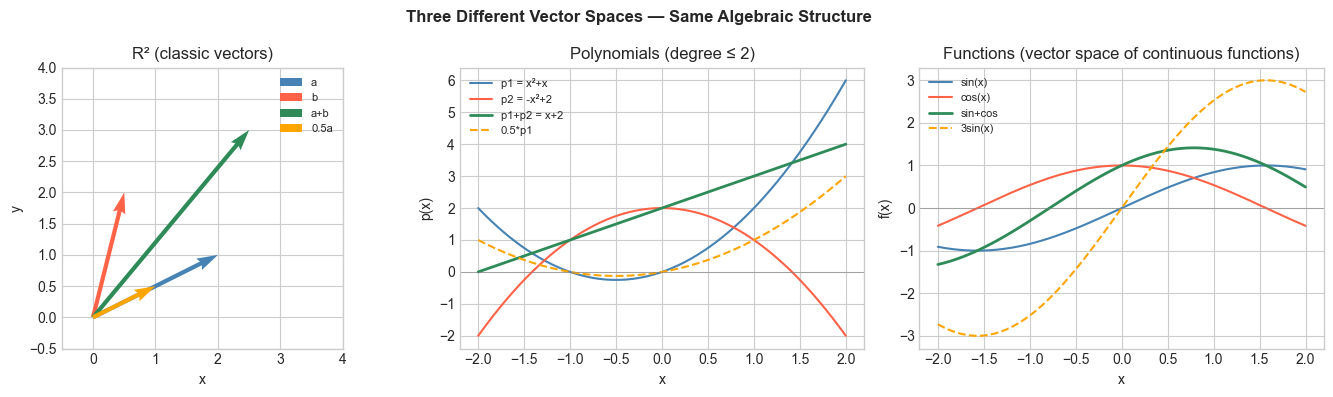

In [1]:
# --- Visualization: Different vector spaces side by side ---
# Show that R^2, polynomials, and functions all behave like vector spaces.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

x = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- R^2: standard vectors ---
ax = axes[0]
a = np.array([2.0, 1.0])
b = np.array([0.5, 2.0])
c = a + b           # closure under addition
s = 0.5 * a         # closure under scaling

kw = dict(angles='xy', scale_units='xy', scale=1, width=0.015)
ax.quiver(0,0,a[0],a[1], color='steelblue', **kw, label='a')
ax.quiver(0,0,b[0],b[1], color='tomato',    **kw, label='b')
ax.quiver(0,0,c[0],c[1], color='seagreen',  **kw, label='a+b')
ax.quiver(0,0,s[0],s[1], color='orange',    **kw, label='0.5a')
ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4)
ax.set_aspect('equal')
ax.set_title('R² (classic vectors)')
ax.legend(fontsize=8)
ax.set_xlabel('x'); ax.set_ylabel('y')

# --- Polynomials up to degree 2 ---
ax = axes[1]
p1 = x**2 + x      # 1*x^2 + 1*x + 0
p2 = -x**2 + 2     # -1*x^2 + 0*x + 2
p_sum = p1 + p2     # closure: still a polynomial
p_scaled = 0.5 * p1 # closure: still a polynomial

ax.plot(x, p1,       color='steelblue', label='p1 = x²+x')
ax.plot(x, p2,       color='tomato',    label='p2 = -x²+2')
ax.plot(x, p_sum,    color='seagreen',  label='p1+p2 = x+2', linewidth=2)
ax.plot(x, p_scaled, color='orange',    label='0.5*p1', linestyle='--')
ax.axhline(0, color='gray', linewidth=0.4)
ax.set_title('Polynomials (degree ≤ 2)')
ax.legend(fontsize=8); ax.set_xlabel('x'); ax.set_ylabel('p(x)')

# --- Functions: sin and cos ---
ax = axes[2]
f1 = np.sin(x)
f2 = np.cos(x)
f_sum    = f1 + f2
f_scaled = 3.0 * f1

ax.plot(x, f1,       color='steelblue', label='sin(x)')
ax.plot(x, f2,       color='tomato',    label='cos(x)')
ax.plot(x, f_sum,    color='seagreen',  label='sin+cos', linewidth=2)
ax.plot(x, f_scaled, color='orange',    label='3sin(x)', linestyle='--')
ax.axhline(0, color='gray', linewidth=0.4)
ax.set_title('Functions (vector space of continuous functions)')
ax.legend(fontsize=8); ax.set_xlabel('x'); ax.set_ylabel('f(x)')

plt.suptitle('Three Different Vector Spaces — Same Algebraic Structure', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Mathematical Formulation

A **vector space** over $\mathbb{R}$ is a set $V$ with two operations:
- **Addition:** $(\mathbf{u}, \mathbf{v}) \mapsto \mathbf{u} + \mathbf{v} \in V$
- **Scalar multiplication:** $(c, \mathbf{v}) \mapsto c\mathbf{v} \in V$

satisfying **8 axioms** for all $\mathbf{u}, \mathbf{v}, \mathbf{w} \in V$ and $c, d \in \mathbb{R}$:

| # | Axiom | Meaning |
|---|---|---|
| A1 | $\mathbf{u} + \mathbf{v} = \mathbf{v} + \mathbf{u}$ | Addition is commutative |
| A2 | $(\mathbf{u}+\mathbf{v})+\mathbf{w} = \mathbf{u}+(\mathbf{v}+\mathbf{w})$ | Addition is associative |
| A3 | $\exists\, \mathbf{0}: \mathbf{v} + \mathbf{0} = \mathbf{v}$ | Zero vector exists |
| A4 | $\exists\, {-\mathbf{v}}: \mathbf{v} + (-\mathbf{v}) = \mathbf{0}$ | Additive inverse exists |
| S1 | $1\cdot\mathbf{v} = \mathbf{v}$ | Scalar identity |
| S2 | $c(d\mathbf{v}) = (cd)\mathbf{v}$ | Scalar multiplication is associative |
| S3 | $c(\mathbf{u}+\mathbf{v}) = c\mathbf{u} + c\mathbf{v}$ | Distributive over vector addition |
| S4 | $(c+d)\mathbf{v} = c\mathbf{v} + d\mathbf{v}$ | Distributive over scalar addition |

**Examples of vector spaces:**
- $\mathbb{R}^n$ — $n$-tuples of real numbers
- $\mathcal{P}_k$ — polynomials of degree $\leq k$
- $C[a,b]$ — continuous functions on $[a,b]$
- $\mathbb{R}^{m\times n}$ — $m\times n$ matrices *(used in Part VI)*

**Non-examples:**
- The positive reals $\mathbb{R}_{>0}$: $-1 \cdot 2 = -2 \notin \mathbb{R}_{>0}$ — not closed under scalar multiplication
- Polynomials of degree exactly $k$: the sum of two degree-$k$ polynomials can have degree $< k$

## 5. Python Implementation

In [2]:
# --- Implementation: Verify the 8 vector space axioms numerically ---
# We test axioms for R^n vectors using random examples.

def check_vector_space_axioms(add_fn, scale_fn, zero_fn, neg_fn, n=5, tol=1e-10):
    """
    Numerically verify the 8 vector space axioms.

    Args:
        add_fn:   (v, w) -> v + w
        scale_fn: (c, v) -> c * v
        zero_fn:  () -> zero vector
        neg_fn:   (v) -> additive inverse of v
        n:        dimension of test vectors
        tol:      numerical tolerance

    Returns:
        dict: axiom name -> bool
    """
    np.random.seed(42)
    u = np.random.randn(n)
    v = np.random.randn(n)
    w = np.random.randn(n)
    c, d = np.random.randn(), np.random.randn()
    zero = zero_fn()

    def close(a, b):
        return np.allclose(a, b, atol=tol)

    return {
        'A1 (commutativity)':       close(add_fn(u, v), add_fn(v, u)),
        'A2 (associativity)':       close(add_fn(add_fn(u, v), w), add_fn(u, add_fn(v, w))),
        'A3 (zero element)':        close(add_fn(v, zero), v),
        'A4 (additive inverse)':    close(add_fn(v, neg_fn(v)), zero),
        'S1 (scalar identity)':     close(scale_fn(1.0, v), v),
        'S2 (scalar assoc)':        close(scale_fn(c, scale_fn(d, v)), scale_fn(c*d, v)),
        'S3 (distrib over vecs)':   close(scale_fn(c, add_fn(u, v)), add_fn(scale_fn(c, u), scale_fn(c, v))),
        'S4 (distrib over scalars)':close(scale_fn(c+d, v), add_fn(scale_fn(c, v), scale_fn(d, v))),
    }


# Test R^n
n = 5
results = check_vector_space_axioms(
    add_fn   = lambda u, v: u + v,
    scale_fn = lambda c, v: c * v,
    zero_fn  = lambda: np.zeros(n),
    neg_fn   = lambda v: -v,
    n=n
)

print(f"Verifying R^{n} as a vector space:")
for axiom, passed in results.items():
    print(f"  {'PASS' if passed else 'FAIL'}  {axiom}")

Verifying R^5 as a vector space:
  PASS  A1 (commutativity)
  PASS  A2 (associativity)
  PASS  A3 (zero element)
  PASS  A4 (additive inverse)
  PASS  S1 (scalar identity)
  PASS  S2 (scalar assoc)
  PASS  S3 (distrib over vecs)
  PASS  S4 (distrib over scalars)


In [3]:
# --- Polynomial vector space ---
# Represent degree-2 polynomials as coefficient vectors [a0, a1, a2]
# p(x) = a0 + a1*x + a2*x^2

# With this representation, addition and scaling are just vector operations.

def poly_eval(coeffs, x):
    """Evaluate polynomial with coefficients [a0, a1, ..., ak] at x."""
    return sum(c * x**i for i, c in enumerate(coeffs))

p1 = np.array([1.0, 2.0, -1.0])   # 1 + 2x - x^2
p2 = np.array([3.0, 0.0,  1.0])   # 3 + x^2

p_sum    = p1 + p2    # same as vector addition
p_scaled = 2.0 * p1   # same as scalar multiplication

x_test = 1.5
print(f"p1({x_test}) + p2({x_test}) = {poly_eval(p1, x_test) + poly_eval(p2, x_test):.4f}")
print(f"(p1+p2)({x_test})          = {poly_eval(p_sum, x_test):.4f}")
print(f"Both equal: {np.isclose(poly_eval(p1, x_test) + poly_eval(p2, x_test),
                                  poly_eval(p_sum, x_test))}")
print("\nPolynomials are a vector space — addition and scaling work identically to R^n")

p1(1.5) + p2(1.5) = 7.0000
(p1+p2)(1.5)          = 7.0000
Both equal: True

Polynomials are a vector space — addition and scaling work identically to R^n


## 6. Experiments

In [4]:
# --- Experiment 1: Non-example — positive reals ---
# Positive reals with standard multiplication and exponentiation can be
# made into a vector space by redefining operations — or they can fail.
# Test: is {v in R^n : v_i > 0} closed under scalar multiplication?

v = np.array([1.0, 2.0, 3.0])  # all positive
c = -1.0  # negative scalar

result = c * v
print(f"v = {v}  (all positive)")
print(f"c * v = {result}  (with c = {c})")
print(f"All positive? {np.all(result > 0)}")
print("\nConclusion: the positive orthant of R^n is NOT a vector space.")
print("It fails closure under negative scalar multiplication (axiom S1 consequences).")

v = [1. 2. 3.]  (all positive)
c * v = [-1. -2. -3.]  (with c = -1.0)
All positive? False

Conclusion: the positive orthant of R^n is NOT a vector space.
It fails closure under negative scalar multiplication (axiom S1 consequences).


In [5]:
# --- Experiment 2: Matrix vector space ---
# The set of all 2x2 matrices forms a vector space.
# Verify the axioms with matrix addition and scalar multiplication.
# Try changing: the matrix entries

A = np.array([[1.0, 2.0], [3.0, 4.0]])  # <-- modify this
B = np.array([[0.0, 1.0], [-1.0, 2.0]]) # <-- modify this
c = 3.0  # <-- modify this

print("A + B =", A + B)
print("B + A =", B + A)
print(f"Commutative (A1): {np.allclose(A+B, B+A)}")
print(f"Zero element (A3): A + 0 = A? {np.allclose(A + np.zeros_like(A), A)}")
print(f"Inverse (A4): A + (-A) = 0? {np.allclose(A + (-A), np.zeros_like(A))}")
print(f"Scalar identity (S1): 1*A = A? {np.allclose(1.0*A, A)}")
print(f"\nMatrices form a vector space of dimension {A.size} (2x2 = 4 free parameters).")

A + B = [[1. 3.]
 [2. 6.]]
B + A = [[1. 3.]
 [2. 6.]]
Commutative (A1): True
Zero element (A3): A + 0 = A? True
Inverse (A4): A + (-A) = 0? True
Scalar identity (S1): 1*A = A? True

Matrices form a vector space of dimension 4 (2x2 = 4 free parameters).


## 7. Exercises

**Easy 1.** Is the set of $2\times 2$ symmetric matrices (where $A = A^T$) a vector space? Check: is the sum of two symmetric matrices symmetric? Is a scalar multiple of a symmetric matrix symmetric? *(Expected: yes — it is a subspace of all $2\times 2$ matrices)*

**Easy 2.** Is the set $\{\mathbf{v} \in \mathbb{R}^3 : v_1 = 1\}$ (first component equals 1) a vector space? *(Expected: no — the zero vector is not in this set)*

**Medium 1.** The set of infinite sequences $(a_0, a_1, a_2, \ldots)$ with component-wise addition and scalar multiplication: is it a vector space? Identify the zero element and additive inverse. What is its dimension? *(Expected: yes, it is; infinite-dimensional)*

**Medium 2.** Write a Python class `PolySpace` that represents polynomials of degree $\leq 3$ as coefficient arrays, with `__add__` and `__rmul__` defined. Verify all 8 axioms using `check_vector_space_axioms`. *(Hint: adapt the lambda functions)*

**Hard.** A **normed vector space** is a vector space equipped with a norm satisfying: positivity, homogeneity ($\|c\mathbf{v}\| = |c|\|\mathbf{v}\|$), and triangle inequality. Show that $\mathbb{R}^n$ with the $L_1$ norm $\|\mathbf{v}\|_1 = \sum_i |v_i|$ is a normed vector space. Verify the triangle inequality numerically for 1000 random pairs.

## 8. Mini Project — Function Space Arithmetic

In [ ]:
# --- Mini Project: Build a discretized function vector space ---
# Problem: Represent continuous functions as discrete sample vectors
#          and verify that they form a vector space.
# Dataset: A small library of basis functions (sin, cos, polynomials).
# Task: Implement FunctionVector, verify axioms, find coordinates in a basis.

N_POINTS = 200
x = np.linspace(0, 2*np.pi, N_POINTS)

class FunctionVector:
    """
    A discretely-sampled function, treated as a vector.

    Args:
        values: array (N,), function samples at fixed x-grid
    """
    def __init__(self, values):
        self.values = np.asarray(values, float)

    def __add__(self, other):
        # TODO: return new FunctionVector with element-wise sum
        pass

    def __rmul__(self, scalar):
        # TODO: return new FunctionVector scaled by scalar
        pass

    def dot(self, other):
        # TODO: inner product = sum of products (discretized integral)
        pass

    def norm(self):
        return np.sqrt(self.dot(self))

    def plot(self, ax, label='', **kwargs):
        ax.plot(x, self.values, label=label, **kwargs)


# Basis functions (not orthogonal)
f_sin  = FunctionVector(np.sin(x))
f_cos  = FunctionVector(np.cos(x))
f_sin2 = FunctionVector(np.sin(2*x))

# Target function
f_target = FunctionVector(2*np.sin(x) + 0.5*np.cos(x))

# --- Test (uncomment after implementing) ---
# sum_test = f_sin + f_cos
# scaled   = 3.0 * f_sin
#
# fig, ax = plt.subplots(figsize=(10, 4))
# f_sin.plot(ax, label='sin(x)', color='steelblue')
# f_cos.plot(ax, label='cos(x)', color='tomato')
# sum_test.plot(ax, label='sin+cos', color='seagreen', linewidth=2)
# scaled.plot(ax, label='3*sin', color='orange', linestyle='--')
# ax.legend(); ax.set_xlabel('x'); ax.set_title('Function Space Arithmetic')
# plt.tight_layout(); plt.show()
#
# # Find approximate coordinates of f_target in {sin, cos} basis
# c1 = f_target.dot(f_sin) / f_sin.dot(f_sin)
# c2 = f_target.dot(f_cos) / f_cos.dot(f_cos)
# print(f"Coordinates: c1={c1:.4f} (expect ~2.0), c2={c2:.4f} (expect ~0.5)")

## 9. Chapter Summary & Connections

- A vector space is any set with addition and scalar multiplication satisfying 8 axioms — not just lists of numbers.
- The axioms guarantee: closure, associativity, commutativity, a zero element, additive inverses, and compatible scaling.
- $\mathbb{R}^n$, matrices, polynomials, and functions are all vector spaces — the same theory applies to all.
- Identifying what is (and is not) a vector space is the first step in applying linear algebra.

**Forward connections:**
- This reappears in **ch138 — Subspaces**, where we identify vector spaces living inside larger ones.
- This reappears in **ch139 — Basis and Dimension**, which asks: what is the minimum number of vectors needed to describe all of $V$?
- This is the foundation of **Part VI (Linear Algebra)** — every theorem there assumes a vector space.

**Backward connection:**
- This generalizes **ch121 — What Is a Vector?**, elevating the concrete example of $\mathbb{R}^n$ to an abstract structure.

**Going deeper:** The most important vector spaces in ML are infinite-dimensional: function spaces (for kernels, Gaussian processes), and spaces of probability distributions (for variational inference). The abstraction of this chapter makes those tractable.